In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from astropy.coordinates import EarthLocation, AltAz, SkyCoord, ICRS
from astropy.time import Time
import astropy.units as u

In [3]:
df = pd.read_csv('full_data2.csv')

In [4]:
df

,Hits,Strings,CovMatrStat,MaxTheta,LogPHit,EvCentZ,ZDist,Tripltes,TimeTerm,Qacc,Qtot,Tres,ThetaErr,NCalls,Zenith,Azimuth
0,7,3,3,2.93215,-1.231460,39.5853,187.9950,0.000000e+00,6.32646,14.74020,14.7402,3.68339,1.738860,69,31.113500,143.2640
1,10,5,2,2.19911,-3.721960,122.2410,146.4280,0.000000e+00,69.53550,20.27910,41.2100,31.75540,0.452333,67,63.157100,27.5691
2,8,2,3,2.30383,-0.937356,146.7340,96.1266,4.203900e-45,50.96830,40.86130,43.3106,6.27829,0.959941,57,53.190500,30.8202
3,13,5,3,1.88496,-4.622600,212.9730,108.2890,7.006490e-45,206.45100,23.11940,107.3790,38.79730,0.973301,64,92.738600,341.2320
4,12,4,-1,1.98968,-2.857600,135.6160,149.0560,2.802600e-45,250.27400,56.01260,60.8593,11.54370,0.000000,231,62.365600,63.2526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16280,7,3,3,2.93215,-0.529329,97.5244,296.3760,0.000000e+00,33.20990,31.17100,36.0127,19.70240,0.341221,279,18.801400,66.5153
16281,9,3,3,2.61799,-2.110020,105.5860,51.6329,4.203900e-45,5.28030,38.58140,38.5814,2.78952,2.112080,121,87.047600,65.3056
16282,7,3,2,3.03687,-5.316770,-92.8394,110.1990,0.000000e+00,24.36560,2.30346,50.5185,7.24683,0.808818,601,56.088900,93.5034
16283,11,3,-1,3.03687,-2.824580,84.7626,282.0030,4.203900e-45,137.37800,28.02580,38.4410,8.11643,0.000000,102,0.000595,158.3780


In [14]:
filtered_df = df[
    (df['Hits'] >= 8) &
    (df['Strings'] >= 2) &
    (df['CovMatrStat'] == 3) &
    (df['MaxTheta'] < 1.7) &
    (df['LogPHit'] > -9) &
    (df['EvCentZ'] < 220) &
    (df['ZDist'] > 70) &
    (np.log10(df['TimeTerm'] / (df['Hits'] - 5)) < 1.1) &
    ((df['Qacc'] / df['Qtot']) > 0.05) &
    (df['Tres'] < 60) &
    (df['ThetaErr'] < 2.5) &
    (df['NCalls'] < 350) &
    (df['Zenith'] > 90)
]

In [15]:
filtered_df

,Hits,Strings,CovMatrStat,MaxTheta,LogPHit,EvCentZ,ZDist,Tripltes,TimeTerm,Qacc,Qtot,Tres,ThetaErr,NCalls,Zenith,Azimuth
469,8,3,3,1.151920,-1.309410,193.1850,75.3190,1.401300e-45,14.488200,142.4220,154.6910,8.170520,1.418590,120,123.3620,19.7150
2895,8,3,3,0.837758,-3.997190,-237.0300,199.3890,2.802600e-45,12.700600,14.8804,22.2062,34.834200,0.625928,256,123.8260,28.4758
3296,10,5,3,1.675520,-3.157820,144.6000,111.8180,4.203900e-45,16.375200,239.5860,257.9120,1.699180,0.574946,133,94.3273,220.8890
4120,8,3,3,0.942478,-1.696330,52.5566,85.9773,1.401300e-45,13.315400,122.7610,133.1390,4.819440,1.004470,68,113.4990,67.1636
5233,9,4,3,0.418879,-3.557170,12.8612,259.3170,2.802600e-45,22.967000,53.0204,68.0135,5.974130,0.744033,116,157.1280,80.2344
6077,9,3,3,0.733038,-4.348750,56.6978,154.4840,2.802600e-45,17.227300,134.0560,143.5680,5.556520,0.517290,87,128.6550,36.1550
6568,9,4,3,0.837758,-2.656530,-158.4700,293.9510,2.802600e-45,39.904800,80.6138,152.4400,31.643000,0.222616,65,168.5650,300.5220
6913,9,4,3,1.675520,-3.260880,216.5330,112.3710,1.401300e-45,29.958500,39.3401,51.3029,9.092780,0.948652,156,92.9795,305.9710
7806,11,4,3,1.675520,-2.476250,-208.1400,116.1770,4.203900e-45,39.042000,83.4895,106.3270,8.562210,0.942016,53,90.7654,241.5530
8141,8,4,3,1.675520,-3.609940,209.8940,89.2505,1.401300e-45,1.594130,14.1620,21.0307,1.921060,1.143120,65,107.0660,82.8486


In [16]:
deg_to_grad = np.pi / 180
rad_to_deg = 180 / np.pi
print(deg_to_grad, rad_to_deg)

0.017453292519943295 57.29577951308232


In [17]:
#координаты телескопа
lat = 51 + 46/60
lon = 104 + 24/60
location = EarthLocation(lat=lat*u.deg, lon=lon*u.deg)
#я возьму дату 1 января 2019 года
date = Time('2019-01-01 00:00:00', scale='utc')

In [18]:
zenith = filtered_df['Zenith'].values
azimuth = filtered_df['Azimuth'].values
rng = np.random.default_rng(seed=42)
ra_list = []
dec_list = []

In [19]:
for i in range(len(zenith)):
    offset_sec = rng.uniform(0, 86400)
    obstime = date + offset_sec * u.s  

    # Высота = 90 - зенитный угол
    alt = 90 - zenith[i]
    az = azimuth[i]

    # Создаём горизонтальные координаты
    altaz = AltAz(alt=alt*u.deg, az=az*u.deg, obstime=obstime, location=location)

    # Преобразуем в RA/Dec
    coord = SkyCoord(altaz).transform_to(ICRS)

   
    ra_list.append(coord.ra.deg)
    dec_list.append(coord.dec.deg)

In [20]:
filtered_df['ra'] = ra_list
filtered_df['dec'] = dec_list

C:\Users\User\AppData\Local\Temp\ipykernel_12980\1522913016.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['ra'] = ra_list
C:\Users\User\AppData\Local\Temp\ipykernel_12980\1522913016.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['dec'] = dec_list


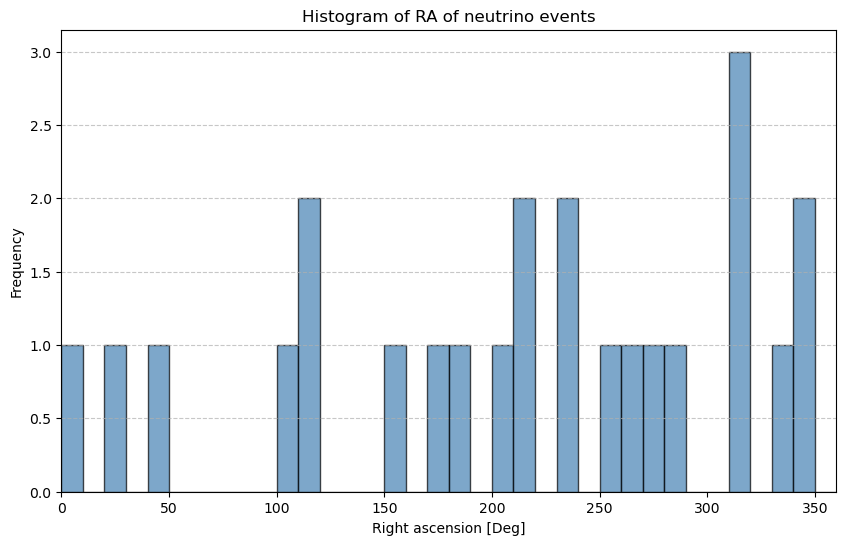

In [21]:
plt.figure(figsize=(10,6))
plt.hist(ra_list, bins=36, range=(0,360), color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Right ascension [Deg]')
plt.ylabel('Frequency')
plt.title('Histogram of RA of neutrino events')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0,360)
plt.show()

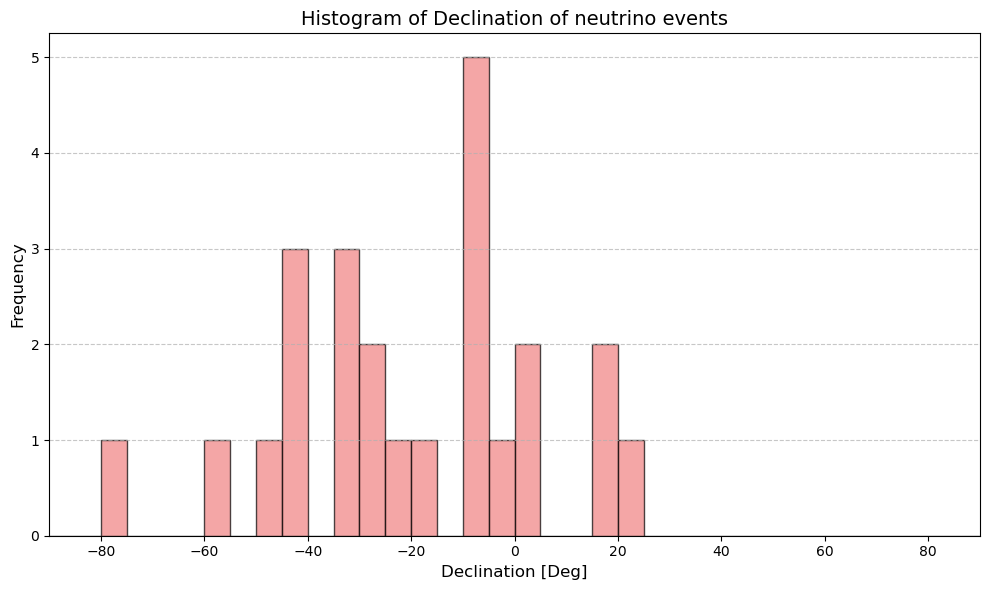

In [22]:
plt.figure(figsize=(10, 6))
counts_dec, bins_dec, patches_dec = plt.hist(dec_list, bins=36, range=(-90, 90),
                                              color='lightcoral', edgecolor='black', alpha=0.7)

plt.xlabel('Declination [Deg]', fontsize=12)
plt.ylabel('Frequency', fontsize=12)  
plt.title('Histogram of Declination of neutrino events', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(-90, 90)

plt.tight_layout()
plt.show()

In [23]:
filtered_df

,Hits,Strings,CovMatrStat,MaxTheta,LogPHit,EvCentZ,ZDist,Tripltes,TimeTerm,Qacc,Qtot,Tres,ThetaErr,NCalls,Zenith,Azimuth,ra,dec
469,8,3,3,1.151920,-1.309410,193.1850,75.3190,1.401300e-45,14.488200,142.4220,154.6910,8.170520,1.418590,120,123.3620,19.7150,287.525137,3.098705
2895,8,3,3,0.837758,-3.997190,-237.0300,199.3890,2.802600e-45,12.700600,14.8804,22.2062,34.834200,0.625928,256,123.8260,28.4758,159.606197,0.938021
3296,10,5,3,1.675520,-3.157820,144.6000,111.8180,4.203900e-45,16.375200,239.5860,257.9120,1.699180,0.574946,133,94.3273,220.8890,104.396293,-31.693628
4120,8,3,3,0.942478,-1.696330,52.5566,85.9773,1.401300e-45,13.315400,122.7610,133.1390,4.819440,1.004470,68,113.4990,67.1636,218.165751,-5.251885
5233,9,4,3,0.418879,-3.557170,12.8612,259.3170,2.802600e-45,22.967000,53.0204,68.0135,5.974130,0.744033,116,157.1280,80.2344,26.930673,-43.161705
6077,9,3,3,0.733038,-4.348750,56.6978,154.4840,2.802600e-45,17.227300,134.0560,143.5680,5.556520,0.517290,87,128.6550,36.1550,349.117947,-5.865324
6568,9,4,3,0.837758,-2.656530,-158.4700,293.9510,2.802600e-45,39.904800,80.6138,152.4400,31.643000,0.222616,65,168.5650,300.5220,313.195744,-45.109161
6913,9,4,3,1.675520,-3.260880,216.5330,112.3710,1.401300e-45,29.958500,39.3401,51.3029,9.092780,0.948652,156,92.9795,305.9710,6.891840,18.690603
7806,11,4,3,1.675520,-2.476250,-208.1400,116.1770,4.203900e-45,39.042000,83.4895,106.3270,8.562210,0.942016,53,90.7654,241.5530,183.355476,-17.671381
8141,8,4,3,1.675520,-3.609940,209.8940,89.2505,1.401300e-45,1.594130,14.1620,21.0307,1.921060,1.143120,65,107.0660,82.8486,113.282927,-8.982567


In [23]:
filtered_df.to_csv('filtered_data.csv', index = False)
ra = filtered_df['ra'].values
dec = filtered_df['dec'].values

In [24]:
coords = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame='icrs')

In [25]:
ra_rad = np.radians(coords.ra.wrap_at(180*u.degree).degree)
dec_rad = np.radians(coords.dec.degree)

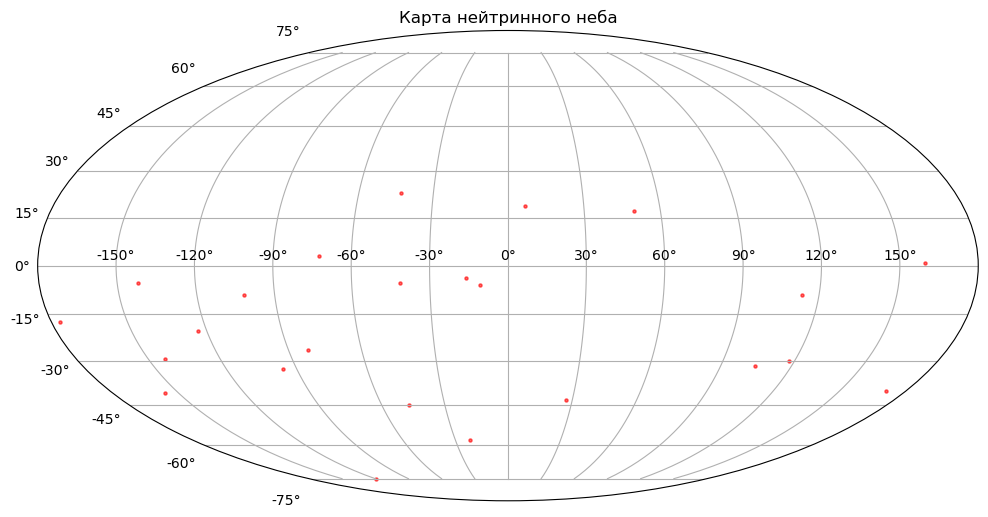

In [30]:
plt.figure(figsize=(10, 6))
ax = plt.subplot(111, projection='mollweide')
ax.scatter(ra_rad, dec_rad, s=5, alpha=0.6, color='red')
ax.grid(True)
ax.set_title('Карта нейтринного неба')
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
fs_df = pd.read_csv('basic3_simulation.txt', 
                    comment='#',           
                    delim_whitespace=True, 
                    header=None,           
                    names=['Dec', 'RA', 'Redshift', 'A'])  

C:\Users\User\AppData\Local\Temp\ipykernel_12980\488210673.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fs_df = pd.read_csv('basic3_simulation.txt',


In [5]:
fs_df

,Dec,RA,Redshift,A
0,-51.2511,154.1463,2.0719,5.921913e-10
1,-32.9652,347.9957,5.0783,5.744078e-11
2,-8.3827,346.9032,3.3038,1.748203e-10
3,39.4964,307.0834,2.7544,2.809087e-10
4,46.1752,106.0016,1.4385,1.543657e-09
...,...,...,...,...
118,65.2109,338.9273,4.3890,8.367949e-11
119,56.0709,138.9969,2.5552,3.418457e-10
120,-15.0512,346.0286,3.7236,1.281048e-10
121,-75.7165,325.9262,4.4236,8.199767e-11


In [6]:
ra = fs_df['RA'].values
dec = fs_df['Dec'].values
flux_A = fs_df['A'].values
redshift = fs_df['Redshift'].values

In [7]:
# Пороги чувствительности для разных полушарий
threshold_north = 1e-9   # Север (Dec > 0)
threshold_south = 5e-9   # Юг (Dec < 0)

selected_mask = (dec > 0) & (flux_A >= threshold_north) | (dec <= 0) & (flux_A >= threshold_south)

# Топ-20% самых ярких среди отобранных
selected_fluxes = flux_A[selected_mask]
if len(selected_fluxes) > 0:
    hot_spot_threshold = np.percentile(selected_fluxes, 80)
    hot_spot_mask = selected_mask & (flux_A >= hot_spot_threshold)
else:
    hot_spot_mask = np.zeros(len(df), dtype=bool)

print(f"Всего источников в симуляции: {len(fs_df)}")
print(f"Отобрано по порогу: {np.sum(selected_mask)} ({np.sum(selected_mask)/len(fs_df)*100:.1f}%)")
print(f"Hot Spots (топ 20%): {np.sum(hot_spot_mask)}")
print(f"Пороги: Север = {threshold_north:.1e}, Юг = {threshold_south:.1e} GeV/cm²·s")

Всего источников в симуляции: 123
Отобрано по порогу: 17 (13.8%)
Hot Spots (топ 20%): 4
Пороги: Север = 1.0e-09, Юг = 5.0e-09 GeV/cm²·s


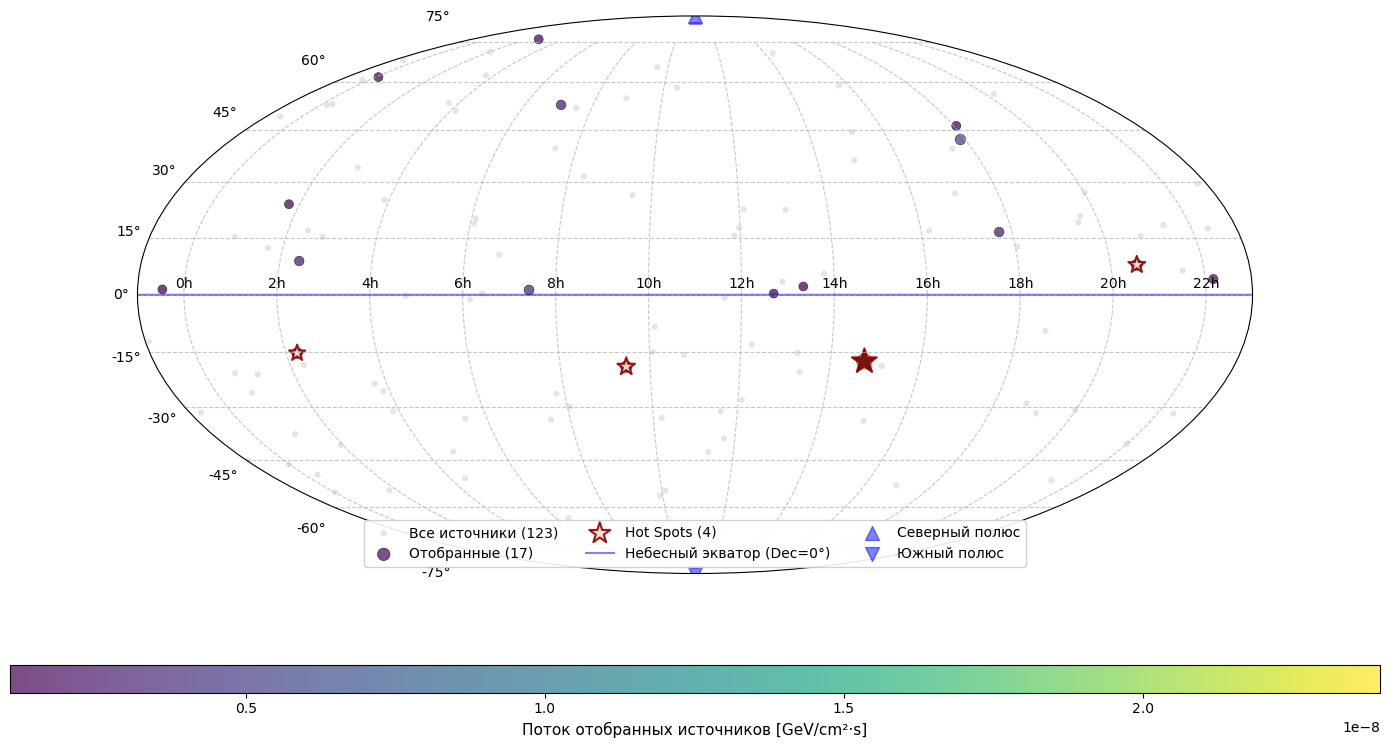

In [8]:
plt.figure(figsize=(14, 8))
ax = plt.subplot(111, projection='mollweide')

ra_deg = ra.copy()
ra_aitoff_deg = np.where(ra_deg > 180, ra_deg - 360, ra_deg)
ra_rad = np.radians(ra_aitoff_deg)
dec_rad = np.radians(dec)

# 1. Все источники (серые, полупрозрачные)
ax.scatter(ra_rad, dec_rad, s=20, color='gray', alpha=0.2, edgecolor='none',
           label=f'Все источники ({len(fs_df)})')

# 2. Отобранные источники 
if np.sum(selected_mask) > 0:
    selected_ra_rad = ra_rad[selected_mask]
    selected_dec_rad = dec_rad[selected_mask]
    selected_flux = flux_A[selected_mask]
    sizes = 40 + 80 * (selected_flux - selected_flux.min()) / (selected_flux.max() - selected_flux.min())
    sc = ax.scatter(selected_ra_rad, selected_dec_rad,
                    c=selected_flux, s=sizes, cmap='viridis',
                    edgecolor='black', linewidth=0.5, alpha=0.7,
                    label=f'Отобранные ({np.sum(selected_mask)})')

# 3. Hot Spots
if np.sum(hot_spot_mask) > 0:
    hot_ra_rad = ra_rad[hot_spot_mask]
    hot_dec_rad = dec_rad[hot_spot_mask]
    hot_flux = flux_A[hot_spot_mask]
    hot_sizes = 150 + 200 * (hot_flux - hot_flux.min()) / (hot_flux.max() - hot_flux.min())
    ax.scatter(hot_ra_rad, hot_dec_rad, c=hot_flux, s=hot_sizes,
               cmap='Reds', edgecolor='darkred', linewidth=1.5,
               alpha=0.9, marker='*', label=f'Hot Spots ({np.sum(hot_spot_mask)})')
    
ax.grid(True, linestyle='--', alpha=0.7)
equator_ra = np.radians(np.linspace(-180, 180, 100))
equator_dec = np.zeros(100)
ax.plot(equator_ra, equator_dec, 'b-', linewidth=1.5, alpha=0.5, label='Небесный экватор (Dec=0°)')
ax.scatter(0, np.radians(90), s=100, marker='^', color='blue', alpha=0.5, label='Северный полюс')
ax.scatter(0, np.radians(-90), s=100, marker='v', color='blue', alpha=0.5, label='Южный полюс')
hour_labels = ['0h', '2h', '4h', '6h', '8h', '10h', '12h', '14h', '16h', '18h', '20h', '22h']
hour_positions = np.linspace(-np.pi, np.pi, 13)[:-1] + np.pi/12
ax.set_xticks(hour_positions)
ax.set_xticklabels(hour_labels)

ax.legend(loc='lower center', fontsize=10, framealpha=0.9, ncol=3)

if np.sum(selected_mask) > 0:
    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.12, aspect=50)
    cbar.set_label('Поток отобранных источников [GeV/cm²·s]', fontsize=11)

plt.tight_layout()
plt.show()

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.stats import chi2
from astropy.coordinates import SkyCoord
import astropy.units as u

In [24]:
events_ra = filtered_df['ra'].values      
events_dec = filtered_df['dec'].values   
N_events = len(filtered_df)

print(f"Загружено событий: {N_events}")

Загружено событий: 24


In [25]:
src_ra = fs_df['RA'].values        # градусы
src_dec = fs_df['Dec'].values      # градусы
src_flux = fs_df['A'].values       # поток A [GeV/cm²/s]
M_sources = len(fs_df)

print(f"Загружено источников: {M_sources}")

Загружено источников: 123


In [38]:
def angular_distance_matrix(ra1, dec1, ra2, dec2):
    """
    ra1, dec1 : массивы координат событий (градусы)
    ra2, dec2 : массивы координат источников (градусы)
    Возвращает матрицу угловых расстояний в радианах размером (len(ra1), len(ra2))
    """
    ra1_rad = np.radians(ra1)[:, np.newaxis]
    dec1_rad = np.radians(dec1)[:, np.newaxis]
    ra2_rad = np.radians(ra2)[np.newaxis, :]
    dec2_rad = np.radians(dec2)[np.newaxis, :]
    
    d_ra = ra1_rad - ra2_rad
    d_dec = dec1_rad - dec2_rad
    a = np.sin(d_dec/2)**2 + np.cos(dec1_rad)*np.cos(dec2_rad)*np.sin(d_ra/2)**2
    return 2 * np.arcsin(np.sqrt(a))

In [52]:
sigma_deg = 0.5
sigma_rad = np.radians(sigma_deg)
# ожидаемое число фоновых событий 
B = 20
area_sky = 4 * np.pi

In [53]:
def log_likelihood_source(rho, src_ra, src_dec, src_flux):
    """
    rho : нормировочный множитель (μ_j = rho * A_j)
    Возвращает логарифм правдоподобия для модели с источниками.
    """
    mu = rho * src_flux
    total_mu = np.sum(mu)
    
    dist = angular_distance_matrix(events_ra, events_dec, src_ra, src_dec)
    gauss = (1.0 / (2 * np.pi * sigma_rad**2)) * np.exp(-dist**2 / (2 * sigma_rad**2))
    source_contrib = mu[np.newaxis, :] * gauss
    prob = B / area_sky + np.sum(source_contrib, axis=1)
    
    logL = np.sum(np.log(prob)) - (B + total_mu)
    return logL

In [57]:
rho0 = N_events / np.sum(src_flux)

# минимизируем отрицательное логарифмическое правдоподобие
result = minimize_scalar(lambda x: -log_likelihood_source(x, src_ra, src_dec, src_flux),
                         bounds=(0, 10*rho0),
                         method='bounded')
best_rho = result.x
logL_source = -result.fun

print(f"Оптимальная нормировка rho = {best_rho:.3e}")
print(f"Максимальное логарифмическое правдоподобие (источники) = {logL_source:.2f}")

Оптимальная нормировка rho = 6.333e-06
Максимальное логарифмическое правдоподобие (источники) = -8.85


In [58]:
logL_null = N_events * np.log(B / area_sky) - B
print(f"Логарифм правдоподобия (только фон) = {logL_null:.2f}")

Логарифм правдоподобия (только фон) = -8.85


In [63]:
Lambda = 2 * (logL_source - logL_null)
print(f"Статистика Λ = {Lambda:.2f}")
k = 1
p_value = 1 - chi2.cdf(Lambda, df=k)

print(f"p-value = {p_value:.2e}")
if p_value < 0.05:
    print("Результат статистически значим (p < 0.05)")
else:
    print("Результат не является статистически значимым")

Статистика Λ = -0.00
p-value = 1.00e+00
Результат не является статистически значимым
